# Lab Experiment 5: Linear Regression through Gradient Descent

## 1. Import Libraries

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.style.use('seaborn-v0_8-whitegrid')

## 2. Import the Dataset

In [22]:
math_df = pd.read_csv("../datasets/student-mat.csv", sep=';')
math_df['subject'] = 'math'


por_df = pd.read_csv("../datasets/student-por.csv", sep=';')
por_df['subject'] = 'portuguese'
df = pd.concat([math_df, por_df], ignore_index=True)

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1044, 34)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,math


## 3. Initial Data Inspection

In [23]:
print('Column data types:')
print(df.dtypes)

print('\nMissing values per column:')
print(df.isnull().sum())

print('\nDuplicate rows:', df.duplicated().sum())

df.describe().T[['mean', 'std', 'min', 'max']]

Column data types:
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
subject         str
dtype: object

Missing values per column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
fam

,mean,std,min,max
age,16.726054,1.239975,15.0,22.0
Medu,2.603448,1.124907,0.0,4.0
Fedu,2.387931,1.099938,0.0,4.0
traveltime,1.522989,0.731727,1.0,4.0
studytime,1.970307,0.834353,1.0,4.0
failures,0.264368,0.656142,0.0,3.0
famrel,3.935824,0.933401,1.0,5.0
freetime,3.201149,1.031507,1.0,5.0
goout,3.156130,1.152575,1.0,5.0
Dalc,1.494253,0.911714,1.0,5.0


## 4. Data Preprocessing

Preprocessing steps used:

- Handle missing values, if present.
- Encode categorical variables using one-hot encoding.
- Select `G3` as the target variable.
- Scale numeric/encoded input features using `StandardScaler` fitted only on the training data.

In [24]:
processed_df = df.copy()

numeric_cols = processed_df.select_dtypes(include=np.number).columns
categorical_cols = processed_df.select_dtypes(exclude=np.number).columns

if processed_df.isnull().sum().sum() > 0:
    processed_df[numeric_cols] = processed_df[numeric_cols].fillna(processed_df[numeric_cols].median())
    for col in categorical_cols:
        processed_df[col] = processed_df[col].fillna(processed_df[col].mode()[0])

X = processed_df.drop(columns=['G3'])
y = processed_df['G3'].astype(float)

X_encoded = pd.get_dummies(X, drop_first=True, dtype=float)

print(f'Feature matrix shape after encoding: {X_encoded.shape}')
print(f'Target vector shape: {y.shape}')
X_encoded.head()

Feature matrix shape after encoding: (1044, 42)
Target vector shape: (1044,)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,subject_portuguese
0,18,4,4,2,2,0,4,3,4,1,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,17,1,1,1,2,0,5,3,3,1,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,15,1,1,1,2,3,4,3,2,2,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
3,15,4,2,1,3,0,3,2,2,1,...,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
4,16,3,3,1,2,0,4,3,2,1,...,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0


## 5. Train-Test Split and Feature Scaling

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

def add_bias_column(X_matrix):
    return np.c_[np.ones(X_matrix.shape[0]), X_matrix]

X_train_b = add_bias_column(X_train_scaled)
X_test_b = add_bias_column(X_test_scaled)

print(f'Training samples: {X_train_b.shape[0]}')
print(f'Testing samples : {X_test_b.shape[0]}')
print(f'Features including bias: {X_train_b.shape[1]}')

Training samples: 835
Testing samples : 209
Features including bias: 43


## 6. Linear Regression Using Batch Gradient Descent


In [26]:
def compute_cost(X_matrix, y_vector, theta):
    errors = X_matrix @ theta - y_vector
    return (errors @ errors) / (2 * len(y_vector))


def gradient_descent(X_matrix, y_vector, learning_rate=0.01, iterations=1000, divergence_limit=1e12):
    theta = np.zeros(X_matrix.shape[1])
    cost_history = []

    for _ in range(iterations):
        errors = X_matrix @ theta - y_vector
        gradient = (X_matrix.T @ errors) / len(y_vector)
        theta = theta - learning_rate * gradient
        cost = compute_cost(X_matrix, y_vector, theta)
        cost_history.append(cost)

        if not np.isfinite(cost) or cost > divergence_limit:
            break

    return theta, np.array(cost_history)


def predict(X_matrix, theta):
    return X_matrix @ theta

## 8. Effect of Different Learning Rates on Convergence

## 7. Visualizing the Parabolic Cost Function

The main dataset has many input features, so its cost surface is high-dimensional and cannot be shown as one simple parabola. To make the idea clear, this section uses only one feature, `G2`, to show how the Linear Regression cost changes with slope and intercept.

For one input feature, Gradient Descent tries to move toward the bottom of the U-shaped cost curve.

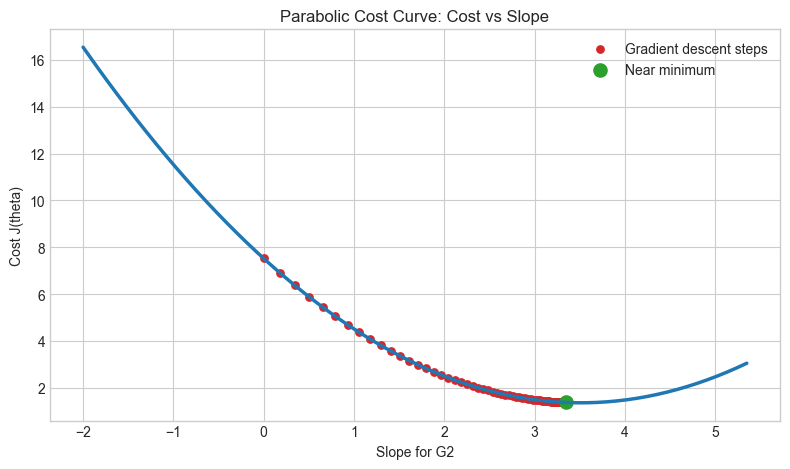

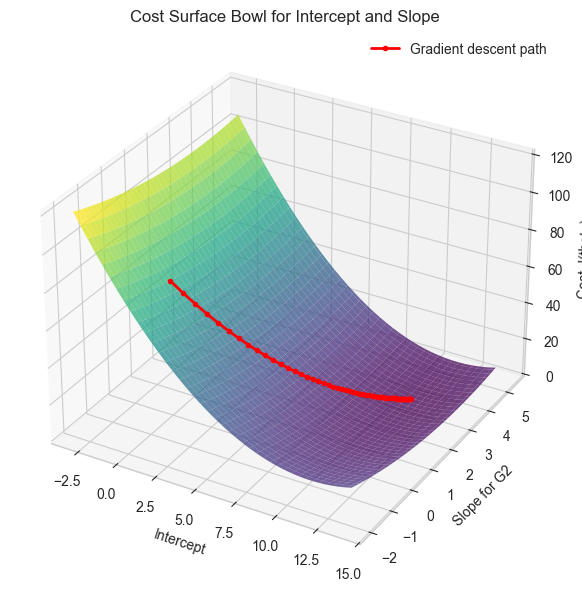

In [27]:
# Use one feature only so the cost surface can be visualized clearly.
simple_feature = 'G2'
X_simple = processed_df[[simple_feature]].astype(float).to_numpy()
y_simple = processed_df['G3'].astype(float).to_numpy()

X_simple_train, _, y_simple_train, _ = train_test_split(
    X_simple, y_simple, test_size=0.20, random_state=RANDOM_STATE
)

simple_scaler = StandardScaler()
X_simple_train_scaled = simple_scaler.fit_transform(X_simple_train).ravel()
X_simple_b = np.c_[np.ones(len(X_simple_train_scaled)), X_simple_train_scaled]

# theta[0] is intercept and theta[1] is slope for this one-feature model.
def gradient_descent_with_path(X_matrix, y_vector, learning_rate=0.05, iterations=60):
    theta = np.zeros(X_matrix.shape[1])
    theta_path = [theta.copy()]
    cost_history = [compute_cost(X_matrix, y_vector, theta)]

    for _ in range(iterations):
        errors = X_matrix @ theta - y_vector
        gradient = (X_matrix.T @ errors) / len(y_vector)
        theta = theta - learning_rate * gradient
        theta_path.append(theta.copy())
        cost_history.append(compute_cost(X_matrix, y_vector, theta))

    return np.array(theta_path), np.array(cost_history)

simple_theta_path, simple_cost_history = gradient_descent_with_path(
    X_simple_b, y_simple_train, learning_rate=0.05, iterations=60
)

best_intercept = simple_theta_path[-1, 0]
slope_values = np.linspace(simple_theta_path[:, 1].min() - 2, simple_theta_path[:, 1].max() + 2, 200)
parabola_costs = []

for slope in slope_values:
    theta_candidate = np.array([best_intercept, slope])
    parabola_costs.append(compute_cost(X_simple_b, y_simple_train, theta_candidate))

path_slopes = simple_theta_path[:, 1]
path_costs_on_slice = [
    compute_cost(X_simple_b, y_simple_train, np.array([best_intercept, slope]))
    for slope in path_slopes
]

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(slope_values, parabola_costs, color='#1f77b4', linewidth=2.5)
ax.scatter(path_slopes, path_costs_on_slice, color='#d62728', s=28, label='Gradient descent steps')
ax.scatter(path_slopes[-1], path_costs_on_slice[-1], color='#2ca02c', s=90, label='Near minimum')
ax.set_title('Parabolic Cost Curve: Cost vs Slope')
ax.set_xlabel('Slope for G2')
ax.set_ylabel('Cost J(theta)')
ax.legend()
plt.tight_layout()
plt.show()

intercept_values = np.linspace(simple_theta_path[:, 0].min() - 3, simple_theta_path[:, 0].max() + 3, 80)
slope_grid_values = np.linspace(simple_theta_path[:, 1].min() - 2, simple_theta_path[:, 1].max() + 2, 80)
intercept_grid, slope_grid = np.meshgrid(intercept_values, slope_grid_values)
cost_grid = np.zeros_like(intercept_grid)

for row in range(intercept_grid.shape[0]):
    for col in range(intercept_grid.shape[1]):
        theta_candidate = np.array([intercept_grid[row, col], slope_grid[row, col]])
        cost_grid[row, col] = compute_cost(X_simple_b, y_simple_train, theta_candidate)

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(intercept_grid, slope_grid, cost_grid, cmap='viridis', alpha=0.75, linewidth=0)
ax.plot(
    simple_theta_path[:, 0],
    simple_theta_path[:, 1],
    simple_cost_history,
    color='red', marker='o', markersize=3, linewidth=2,
    label='Gradient descent path'
)
ax.set_title('Cost Surface Bowl for Intercept and Slope')
ax.set_xlabel('Intercept')
ax.set_ylabel('Slope for G2')
ax.set_zlabel('Cost J(theta)')
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
iterations = 2000

learning_rate_results = []
histories = {}

for lr in learning_rates:
    theta_lr, history = gradient_descent(
        X_train_b, y_train, learning_rate=lr, iterations=iterations
    )
    histories[lr] = history
    learning_rate_results.append({
        'Learning Rate': lr,
        'Iterations Run': len(history),
        'Initial Cost': history[0],
        'Final Cost': history[-1],
        'Converged': bool(len(history) == iterations and np.isfinite(history[-1]) and history[-1] < history[0])
    })

lr_results_df = pd.DataFrame(learning_rate_results)
lr_results_df

,Learning Rate,Iterations Run,Initial Cost,Final Cost,Converged
0,0.001,2000,72.350847,2.429740e+00,True
1,0.010,2000,70.916052,1.076242e+00,True
2,0.050,2000,64.756401,1.074916e+00,True
3,0.100,2000,57.555556,1.074916e+00,True
4,0.500,2000,19.897504,1.074916e+00,True
5,1.000,13,22.696712,1.969656e+12,False


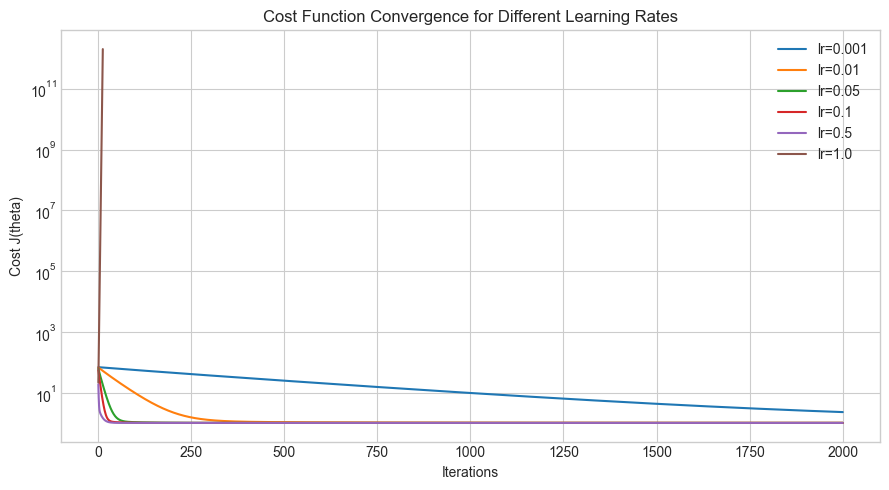

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))

for lr, history in histories.items():
    plot_history = history[np.isfinite(history)]
    if len(plot_history) > 0:
        ax.plot(range(1, len(plot_history) + 1), plot_history, label=f'lr={lr}')

ax.set_title('Cost Function Convergence for Different Learning Rates')
ax.set_xlabel('Iterations')
ax.set_ylabel('Cost J(theta)')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Train Final Model

A learning rate of `0.05` is selected because it reaches the minimum smoothly without unstable behavior.

In [30]:
selected_learning_rate = 0.05
final_iterations = 3000

theta, final_cost_history = gradient_descent(
    X_train_b, y_train, learning_rate=selected_learning_rate, iterations=final_iterations
)

y_train_pred = predict(X_train_b, theta)
y_test_pred = predict(X_test_b, theta)

print(f'Selected learning rate: {selected_learning_rate}')
print(f'Initial training cost : {final_cost_history[0]:.4f}')
print(f'Final training cost   : {final_cost_history[-1]:.4f}')
print(f'Iterations completed  : {len(final_cost_history)}')

Selected learning rate: 0.05
Initial training cost : 64.7564
Final training cost   : 1.0749
Iterations completed  : 3000


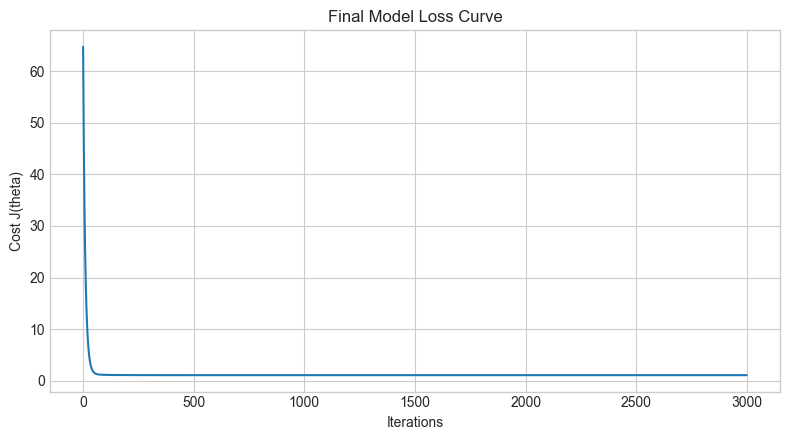

In [31]:
plt.figure(figsize=(8, 4.5))
plt.plot(final_cost_history, color='#1f77b4')
plt.title('Final Model Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('Cost J(theta)')
plt.tight_layout()
plt.show()

## 10. Model Evaluation

In [32]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2 Score': r2_score(y_true, y_pred)
    }

metrics_df = pd.DataFrame([
    {'Split': 'Train', **regression_metrics(y_train, y_train_pred)},
    {'Split': 'Test', **regression_metrics(y_test, y_test_pred)}
])

metrics_df

,Split,MAE,MSE,RMSE,R2 Score
0,Train,0.923236,2.149833,1.466231,0.854369
1,Test,1.016888,3.097365,1.759933,0.799664


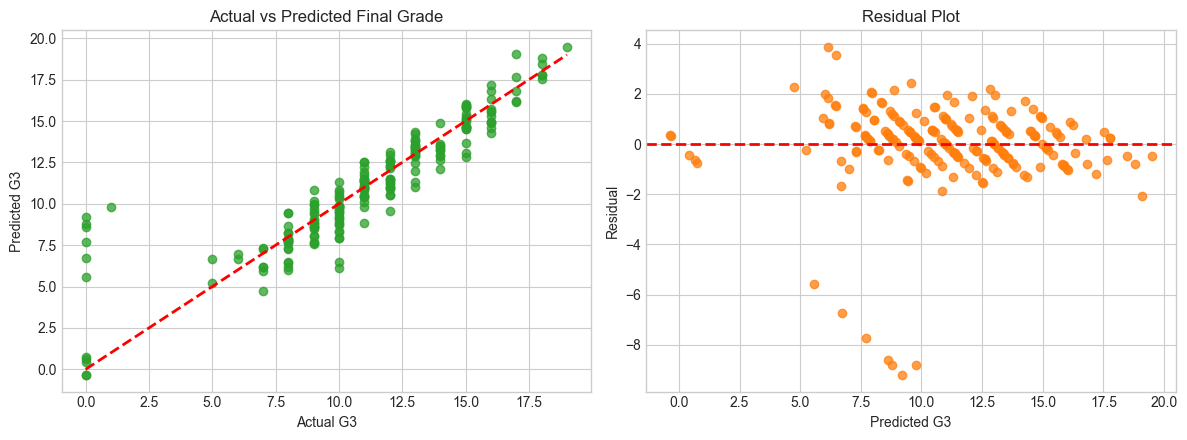

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(y_test, y_test_pred, alpha=0.75, color='#2ca02c')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs Predicted Final Grade')
axes[0].set_xlabel('Actual G3')
axes[0].set_ylabel('Predicted G3')

residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.75, color='#ff7f0e')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted G3')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

## 11. Interpretation

- The cost decreases sharply during the early iterations and then gradually flattens, which indicates convergence.
- Very small learning rates such as `0.001` converge slowly because each update step is tiny.
- Moderate learning rates such as `0.05` and `0.1` converge quickly and remain stable.
- A very large learning rate such as `1.0` overshoots the minimum and causes divergence.
- The test RMSE is around 1.76 grade points and the test R2 score is around 0.80, showing that the Gradient Descent Linear Regression model explains most of the variation in final grades.
- `G1` and `G2` are strong predictors of `G3`, so the model performs reasonably well on unseen data.